# Surrogate Checkpoint Evaluation

For each `.pt` surrogate checkpoint in `checkpoints/`, computes the relative L2 error on the **physical** field U(t) and displays histograms/comparison plots.

Supports all surrogate types: `SLAEModel`, `LLAEModel`, `SLAESVDModel`, `LLAESVDModel`, `CorrectionAE`.

In [20]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

## 1. Dataset loading

In [21]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_surr'      # separate cache from AE notebook
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000
Train: 6480  Test: 1620


In [22]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize U to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation function

`InferencePipeline` handles all model types transparently.

In [23]:
def eval_surrogate(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> np.ndarray:
    """
    Computes L2rel (%) on physical field U for every simulation in idx_list.
    Uses InferencePipeline so it works for any surrogate type.
    Returns np.ndarray of shape (n_samples,).
    """
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]         # (B, 3)
        U_pred = pipe.predict(theta_batch)         # (B, Nt, N, N)

        for j, idx in enumerate(batch_idx):
            U_gt   = load_u(idx)                   # (Nt, N, N)
            denom  = np.linalg.norm(U_gt)
            if denom >= 1e-12:
                l2rel_list.append(
                    np.linalg.norm(U_pred[j] - U_gt) / denom * 100.0
                )

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluate all surrogate checkpoints

In [24]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    try:
        data = np.load(cache_file, allow_pickle=True)
        return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)
    except Exception as e:
        print(f'Failed to load cache {cache_file}: {e}')
        return False

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


def _model_type_from_ckpt(ckpt_path: str) -> str:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    return ckpt.get('model_type', 'SLAEModel')


# ── Main loop ────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

# Surrogate checkpoints are .pt files (AE checkpoints are .ckpt)
# Exclude svd_bases.pt which is not a surrogate
ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if (os.path.basename(p).startswith('SLAEModel') or os.path.basename(p).startswith('LLAEModel'))
        and ("_ll__" in os.path.basename(p) or "_ol" in os.path.basename(p))
        and not os.path.basename(p).startswith('svd_bases')
])
print(f'{len(ckpt_paths)} surrogate checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda

6 surrogate checkpoints found:
  LLAEModel__llae_ld64_K16_g0.0_ll__t4h2.ckpt
  LLAEModel__llae_ld64_K32_g0.0_ll__t4h2.ckpt
  LLAEModel__llae_ld64_K8_g0.0_ll__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.0_ol__t4h2.ckpt
  SLAEModel__slae_ld64_K32_g0.0_ol__t4h2.ckpt
  SLAEModel__slae_ld64_K8_g0.0_ol__t4h2.ckpt


In [25]:
results     = {}   # name → np.array L2rel (%)
model_types = {}   # name → model_type str

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    cache_file = _cache_path(name)

    mtype = _model_type_from_ckpt(ckpt_path)
    model_types[name] = mtype

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}  [{mtype}]')
    else:
        print(f'[compute] {name}  [{mtype}]')
        try:
            l2 = eval_surrogate(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  '
          f'p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

[cache]   LLAEModel__llae_ld64_K16_g0.0_ll__t4h2  [LLAEModel]
   median=4.63%  mean=5.13%  p90=7.65%  n=1620
[cache]   LLAEModel__llae_ld64_K32_g0.0_ll__t4h2  [LLAEModel]
   median=4.58%  mean=5.10%  p90=7.53%  n=1620
[cache]   LLAEModel__llae_ld64_K8_g0.0_ll__t4h2  [LLAEModel]
   median=4.54%  mean=4.99%  p90=7.41%  n=1620
[cache]   SLAEModel__slae_ld64_K16_g0.0_ol__t4h2  [SLAEModel]
   median=7.46%  mean=8.65%  p90=13.38%  n=1620
[cache]   SLAEModel__slae_ld64_K32_g0.0_ol__t4h2  [SLAEModel]
   median=5.04%  mean=5.45%  p90=7.52%  n=1620
[cache]   SLAEModel__slae_ld64_K8_g0.0_ol__t4h2  [SLAEModel]
   median=9.76%  mean=11.01%  p90=15.97%  n=1620

Done.


In [26]:
# ── Plot helpers: palette + human-readable checkpoint names ──────────────
from matplotlib.patches import Patch

# Keyed by the `model_type` stored in the checkpoint (see InferencePipeline).
# SLAE family → blues, LLAE family → warm tones.
PALETTE = {
    'SLAEModel'       : 'steelblue',
    'SLAESVDModel'    : '#7CA6D8',
    'SLAETuckerModel' : '#2B4C7E',
    'LLAEModel'       : 'tomato',
    'LLAESVDModel'    : '#F0946E',
    'LLAETuckerModel' : '#8C2B14',
    'CorrectionAE'    : '#55A868',
}

# AE stem, e.g. 'llae_ld64_K16_g0.01' or 'slae_ld64_K16_g0.0_ol'
_AE_STEM_PAT = re.compile(
    r'^(?P<ae>slae|llae|lslae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)$'
)

# Surrogate ckpt, e.g. 'LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs8rz16[-v1]'
_SURR_PAT = re.compile(
    r'^(?P<cls>[A-Za-z]+Model)__(?P<ae_stem>.+?)__'
    r't(?P<n_trunk>\d+)h(?P<n_head>\d+)(?P<suffix>.*?)(?:-v(?P<ver>\d+))?$'
)


def _fmt_g(g: str) -> str:
    f = float(g)
    return str(int(f)) if f == int(f) else str(f)


def _pretty_name(name: str) -> str:
    """'LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs8rz16' →
       'LLAE-Tucker  d=64, K=16, γ=0.01\nt4h2  r_s=8, r_z=16'

    Checkpoints with a fitted Laplace basis (_ll / _ol) show the tag instead of γ."""
    m = _SURR_PAT.match(name)
    if not m:
        return name
    sm = _AE_STEM_PAT.match(m.group('ae_stem'))
    if not sm:
        return name

    cls   = m.group('cls')
    label = 'LLAE' if cls.startswith('LLAE') else 'SLAE'
    if 'Tucker' in cls:
        label += '-Tucker'
    elif 'SVD' in cls:
        label += '-SVD'

    # With a learnable/optimised Laplace basis (_ll / _ol) the poles are fitted,
    # so gamma_init is meaningless and is replaced by the basis tag.
    head   = f"{label}  d={sm.group('ld')}, K={sm.group('K')}"
    ae_suf = sm.group('ae_suf').strip('_')
    if ae_suf:
        head += f' [{ae_suf}]'
    else:
        head += f", γ={_fmt_g(sm.group('g'))}"

    suffix = m.group('suffix')
    bits   = [f"t{m.group('n_trunk')}h{m.group('n_head')}"]
    rank = re.search(r'rs(\d+)rz(\d+)', suffix)
    if rank:
        bits.append(f'r_s={rank.group(1)}, r_z={rank.group(2)}')
    if m.group('ver'):
        bits.append(f"v{m.group('ver')}")

    return head + '\n' + '  '.join(bits)


## 4. Laplace poles $s_k$ and inversion regularization

Direct surrogates only (`SLAEModel` / `LLAEModel`). Everything is read from the
loaded models (`pipe.model.laplace`): the poles $s_k = \sigma_k + i\omega_k$ actually
used at inference, their initialization buffers, and the effective inversion
regularization $\alpha_t$ (temporal smoothing) and $\lambda$ (ridge).
One figure per family, one panel per checkpoint.


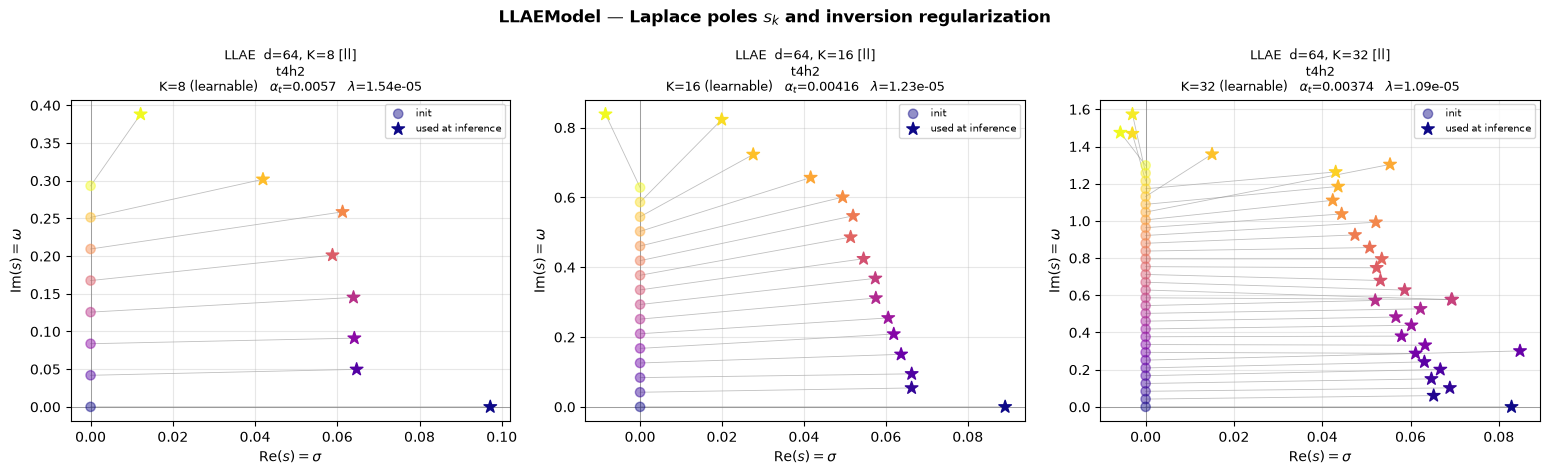

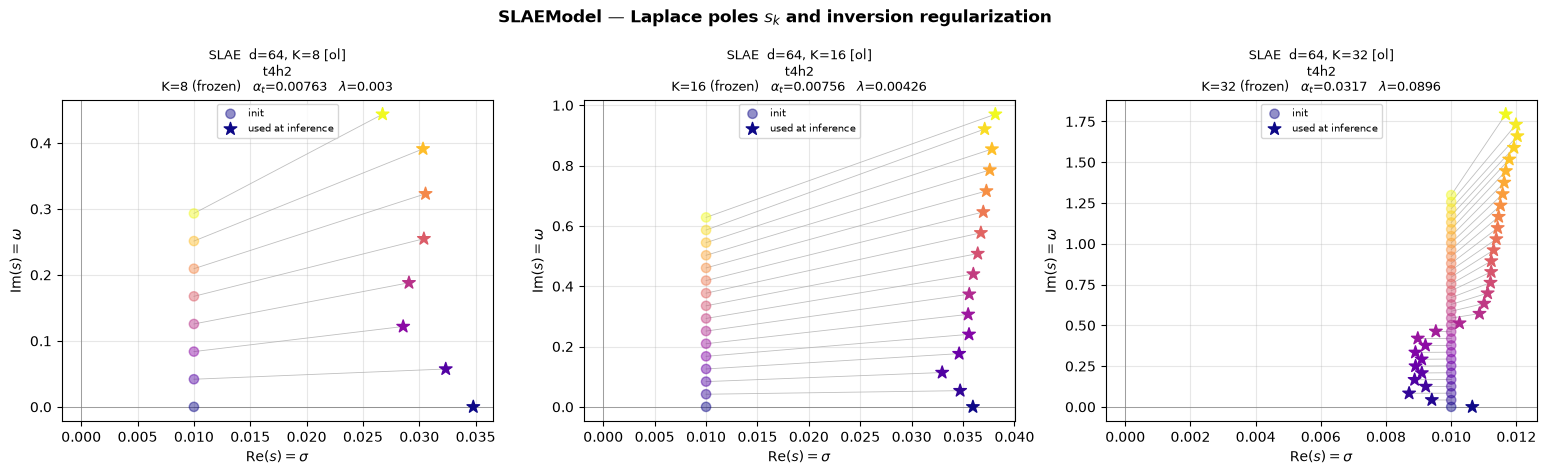

In [27]:
# ── Laplace poles s_k + regularization of the direct surrogates ──────────
pole_info = {}   # name → dict

for ckpt_path in ckpt_paths:
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    if model_types.get(name) not in ('SLAEModel', 'LLAEModel'):
        continue
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device='cpu')
    lap  = pipe.model.laplace
    with torch.no_grad():
        alpha_t = lap.log_alpha_t.exp() if lap.learnable else lap._alpha_t_fixed
        lam     = lap.log_lam.exp()     if lap.learnable else lap._lam_fixed
        pole_info[name] = dict(
            s_cur     = lap.s_list.detach().numpy().copy(),
            s_init    = (lap._s_init_re + 1j * lap._s_init_im).numpy().copy(),
            alpha_t   = float(alpha_t),
            lam       = float(lam),
            learnable = bool(lap.learnable),
            mtype     = pipe.model_type,
        )
    del pipe
gc.collect()

for family in ('LLAEModel', 'SLAEModel'):
    names = sorted(
        [n for n in pole_info if pole_info[n]['mtype'] == family],
        key=lambda n: (len(pole_info[n]['s_cur']), n),
    )
    if not names:
        print(f'No {family} checkpoint found.')
        continue

    fig, axes = plt.subplots(1, len(names), figsize=(5.2 * len(names), 4.8), squeeze=False)
    for ax, n in zip(axes[0], names):
        info = pole_info[n]
        s_cur, s_ini = info['s_cur'], info['s_init']
        K = len(s_cur)
        c = np.arange(K)
        for a, b in zip(s_ini, s_cur):
            ax.plot([a.real, b.real], [a.imag, b.imag], color='gray', lw=0.6, alpha=0.5, zorder=1)
        ax.scatter(s_ini.real, s_ini.imag, c=c, cmap='plasma', s=45, marker='o',
                   alpha=0.45, zorder=3, label='init')
        ax.scatter(s_cur.real, s_cur.imag, c=c, cmap='plasma', s=90, marker='*',
                   zorder=4, label='used at inference')
        ax.axvline(0, color='gray', lw=0.5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel(r'Re$(s) = \sigma$')
        ax.set_ylabel(r'Im$(s) = \omega$')
        tag = 'learnable' if info['learnable'] else 'frozen'
        ax.set_title(
            _pretty_name(n) + '\n'
            + rf'K={K} ({tag})   $\alpha_t$={info["alpha_t"]:.3g}   $\lambda$={info["lam"]:.3g}',
            fontsize=9,
        )
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(f'{family} — Laplace poles $s_k$ and inversion regularization',
                 fontweight='bold')
    fig.tight_layout()
    plt.show()


## 5. Histograms per checkpoint

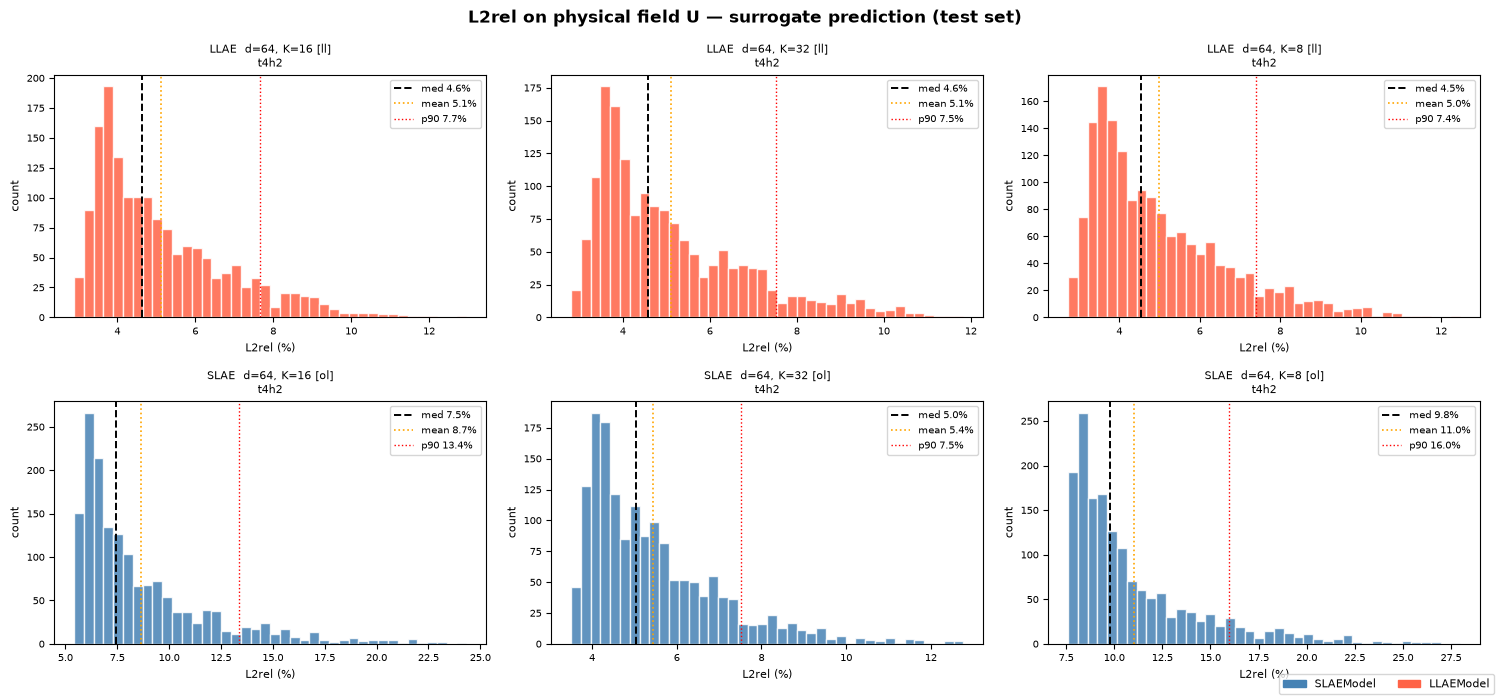

In [28]:

if results:
    names  = list(results.keys())
    n_ckpt = len(names)
    ncols  = min(3, n_ckpt)
    nrows  = (n_ckpt + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    if n_ckpt == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax, name in zip(axes, names):
        l2     = results[name]
        mtype  = model_types.get(name, 'SLAEModel')
        color  = PALETTE.get(mtype, 'gray')
        median = np.median(l2)
        mean   = np.mean(l2)
        p90    = np.percentile(l2, 90)

        ax.hist(l2, bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
        ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
        ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
        ax.set_title(_pretty_name(name), fontsize=8)
        ax.set_xlabel('L2rel (%)', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for ax in axes[n_ckpt:]:
        ax.set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    fig.legend(handles=legend_handles, loc='lower right', fontsize=8, ncol=2)

    fig.suptitle('L2rel on physical field U — surrogate prediction (test set)', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No surrogate checkpoints found in', CKPT_DIR)


## 6. Median comparison

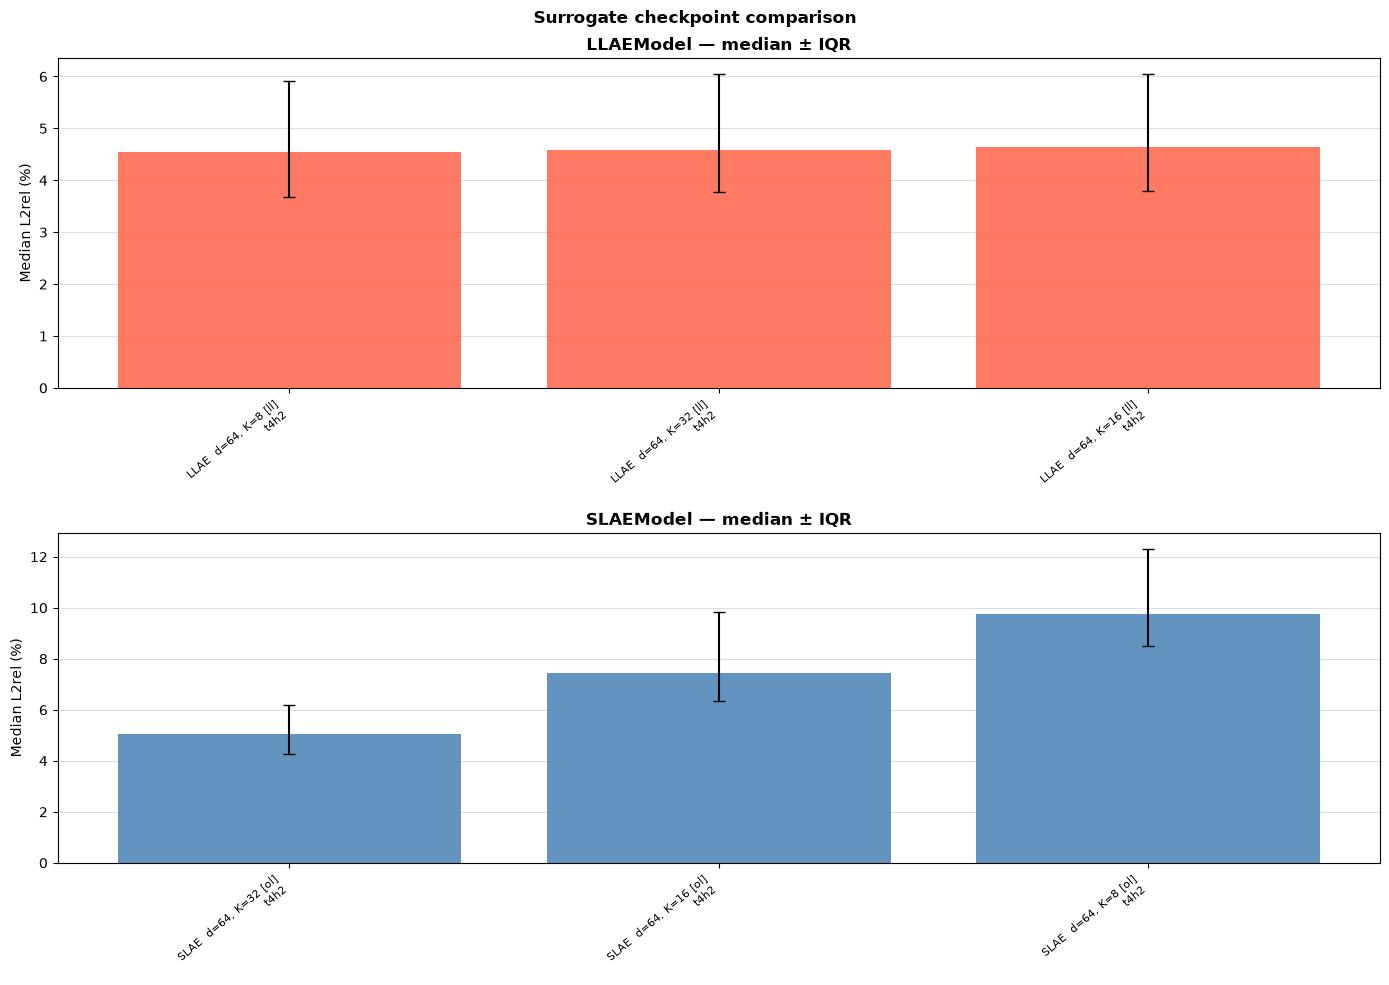

In [29]:
if results:
    medians = {n: float(np.median(v)) for n, v in results.items()}
    p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
    p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

    families = sorted(set(model_types.values()))
    fig, axes = plt.subplots(len(families), 1, figsize=(14, 5 * len(families)))
    if len(families) == 1:
        axes = [axes]

    for ax, family in zip(axes, families):
        names_fam    = [n for n in results if model_types.get(n) == family]
        sorted_names = sorted(names_fam, key=lambda n: medians[n])
        color        = PALETTE.get(family, 'gray')
        x            = np.arange(len(sorted_names))

        ax.bar(x, [medians[n] for n in sorted_names], color=color, alpha=0.85, zorder=2)

        yerr_low  = [medians[n] - p25[n] for n in sorted_names]
        yerr_high = [p75[n] - medians[n] for n in sorted_names]
        ax.errorbar(x, [medians[n] for n in sorted_names],
                    yerr=[yerr_low, yerr_high],
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels([_pretty_name(n) for n in sorted_names],
                           rotation=40, ha='right', fontsize=8)
        ax.set_ylabel('Median L2rel (%)')
        ax.set_title(f'{family} — median ± IQR', fontweight='bold')
        ax.grid(axis='y', alpha=0.4, zorder=0)

    fig.suptitle('Surrogate checkpoint comparison', fontweight='bold', fontsize=12)
    fig.tight_layout()
    plt.show()

## 7. Summary table

In [30]:
if results:
    print(f"{'Config':<60}  {'type':<15}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
    print('-' * 150)
    for n in sorted(results, key=lambda n: np.median(results[n])):
        l2    = results[n]
        mtype = model_types.get(n, '?')
        label = _pretty_name(n).replace('\n', '  ')
        print(f'{label:<60}  {mtype:<15}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  '
              f'{np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Config                                                        type               median      mean       p90      n
------------------------------------------------------------------------------------------------------------------------------------------------------
LLAE  d=64, K=8 [ll]  t4h2                                    LLAEModel           4.54%     4.99%     7.41%   1620
LLAE  d=64, K=32 [ll]  t4h2                                   LLAEModel           4.58%     5.10%     7.53%   1620
LLAE  d=64, K=16 [ll]  t4h2                                   LLAEModel           4.63%     5.13%     7.65%   1620
SLAE  d=64, K=32 [ol]  t4h2                                   SLAEModel           5.04%     5.45%     7.52%   1620
SLAE  d=64, K=16 [ol]  t4h2                                   SLAEModel           7.46%     8.65%    13.38%   1620
SLAE  d=64, K=8 [ol]  t4h2                                    SLAEModel           9.76%    11.01%    15.97%   1620


## 8. Family ablation plots

Violin plots showing the effect of each hyperparameter, grouping by model family.

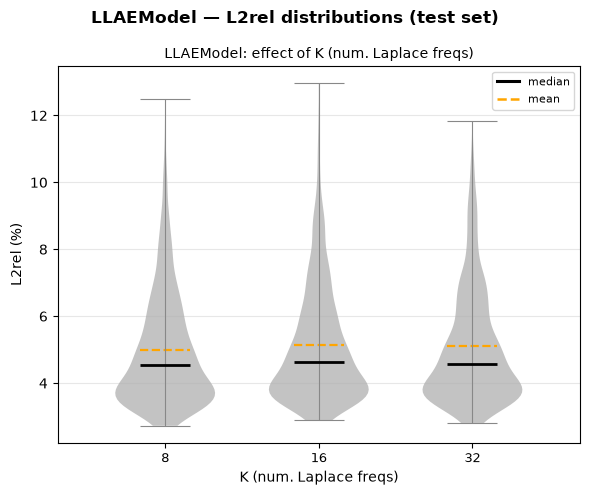

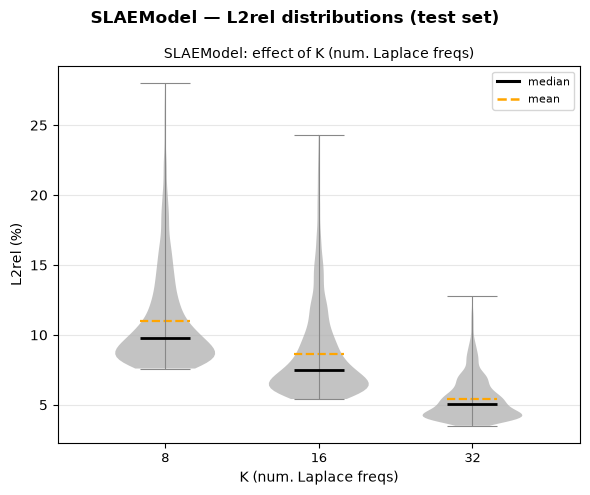

In [31]:
from collections import defaultdict
from matplotlib.lines import Line2D

# Parse surrogate checkpoint name into structured dict
def _parse_surr_name(name: str) -> dict | None:
    m = _SURR_PAT.match(name)
    if not m:
        return None
    ae_stem = m.group('ae_stem')
    cls     = m.group('cls')

    ae_m = re.match(r'^(?P<ae>[a-z]+)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)', ae_stem)
    if not ae_m:
        return None

    return {
        'name'   : name,
        'cls'    : cls,
        'ae'     : ae_m.group('ae'),
        'ld'     : int(ae_m.group('ld')),
        'K'      : int(ae_m.group('K')),
        'gamma'  : float(ae_m.group('g')),
        'n_trunk': int(m.group('n_trunk')),
        'n_head' : int(m.group('n_head')),
    }

parsed_rows = [r for r in (_parse_surr_name(n) for n in results) if r is not None]


def _violin_ablation(ax, rows, var_name, xlabel, title):
    """Draw one violin per value of `var_name`."""
    if not rows:
        ax.set_title(f"{title}\n(no data)"); ax.axis('off'); return

    xs_vals = sorted(set(r[var_name] for r in rows))

    legend_handles = [
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ]

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    positions = [i for i, v in enumerate(xs_vals) if v in groups]
    datasets  = [groups[v] for v in xs_vals if v in groups]
    if datasets:
        parts = ax.violinplot(datasets, positions=positions, widths=0.65,
                              showmedians=True, showmeans=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor('#888888'); pc.set_alpha(0.5)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.0)
        parts['cmeans'].set_color('orange');  parts['cmeans'].set_linewidth(1.6)
        parts['cmeans'].set_linestyle('--')
        for key in ('cmaxes', 'cmins', 'cbars'):
            parts[key].set_color('#888888'); parts[key].set_linewidth(0.8)

    ax.set_xticks(range(len(xs_vals)))
    ax.set_xticklabels([str(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=legend_handles, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


# One figure per family; ablations: K, ld, n_trunk
families = sorted(set(r['cls'] for r in parsed_rows))

for family in families:
    frows = [r for r in parsed_rows if r['cls'] == family]
    if not frows:
        continue

    ablations = []
    for var, xlabel in [
        ('K',      'K (num. Laplace freqs)'),
        ('ld',     'latent dim'),
        ('n_trunk','n_trunk'),
    ]:
        if len(set(r[var] for r in frows)) > 1:
            ablations.append((var, xlabel))

    if not ablations:
        print(f'{family}: only one configuration found, skipping ablation plot.')
        continue

    fig, axes = plt.subplots(1, len(ablations), figsize=(6 * len(ablations), 5))
    if len(ablations) == 1:
        axes = [axes]

    for ax, (var, xlabel) in zip(axes, ablations):
        _violin_ablation(ax, frows, var, xlabel, f'{family}: effect of {xlabel}')

    fig.suptitle(f'{family} — L2rel distributions (test set)', fontweight='bold')
    fig.tight_layout()
    plt.show()


## 9. Inference latency benchmark

In [32]:
N_BENCH      = 200
N_WARMUP_LAT = 10
N_RUNS_LAT   = 50

# Pre-load theta for the benchmark samples (lightweight, no U needed for surrogate)
bench_theta = theta_np[test_idx[:N_BENCH]]   # (N_BENCH, 3)
print(f'Benchmark theta shape: {bench_theta.shape}')

bench = {}

def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True)
    ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record()
        torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)


for ckpt_path in tqdm(ckpt_paths, desc='latency benchmark'):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        theta_dev = torch.tensor(bench_theta[:1], dtype=torch.float32, device=device)
        theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        theta_norm = (theta_dev - theta_mean) / theta_std

        if device == 'cuda':
            def lat_fn():
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
            lat_ms = _time_gpu(lat_fn, N_WARMUP_LAT, N_RUNS_LAT)
            bench[name] = dict(lat_med=np.median(lat_ms), lat_std=np.std(lat_ms))
        else:
            import time
            times = []
            for _ in range(N_RUNS_LAT + N_WARMUP_LAT):
                t0 = time.perf_counter()
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
                times.append((time.perf_counter() - t0) * 1e3)
            times = np.array(times[N_WARMUP_LAT:])
            bench[name] = dict(lat_med=np.median(times), lat_std=np.std(times))

        mtype = pipe.model_type
        print(f'{name:<55}  lat={bench[name]["lat_med"]:6.1f}±{bench[name]["lat_std"]:.1f} ms  [{mtype}]')

        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

Benchmark theta shape: (200, 3)


latency benchmark:   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_1996557/3404931686.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_1996557/3404931686.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
latency benchmark:  17%|█▋        | 1/6 [00:12<01:04, 12.91s/it]

LLAEModel__llae_ld64_K16_g0.0_ll__t4h2                   lat= 182.7±16.8 ms  [LLAEModel]


latency benchmark:  33%|███▎      | 2/6 [00:23<00:46, 11.70s/it]

LLAEModel__llae_ld64_K32_g0.0_ll__t4h2                   lat= 184.4±46.8 ms  [LLAEModel]


...

SLAEModel__slae_ld64_K16_g0.0_ol__t4h2                   lat= 115.8±11.1 ms  [SLAEModel]


latency benchmark:  83%|████████▎ | 5/6 [00:57<00:11, 11.52s/it]

SLAEModel__slae_ld64_K32_g0.0_ol__t4h2                   lat= 166.0±39.0 ms  [SLAEModel]


latency benchmark: 100%|██████████| 6/6 [01:01<00:00, 10.30s/it]

SLAEModel__slae_ld64_K8_g0.0_ol__t4h2                    lat=  87.3±34.4 ms  [SLAEModel]

Done.


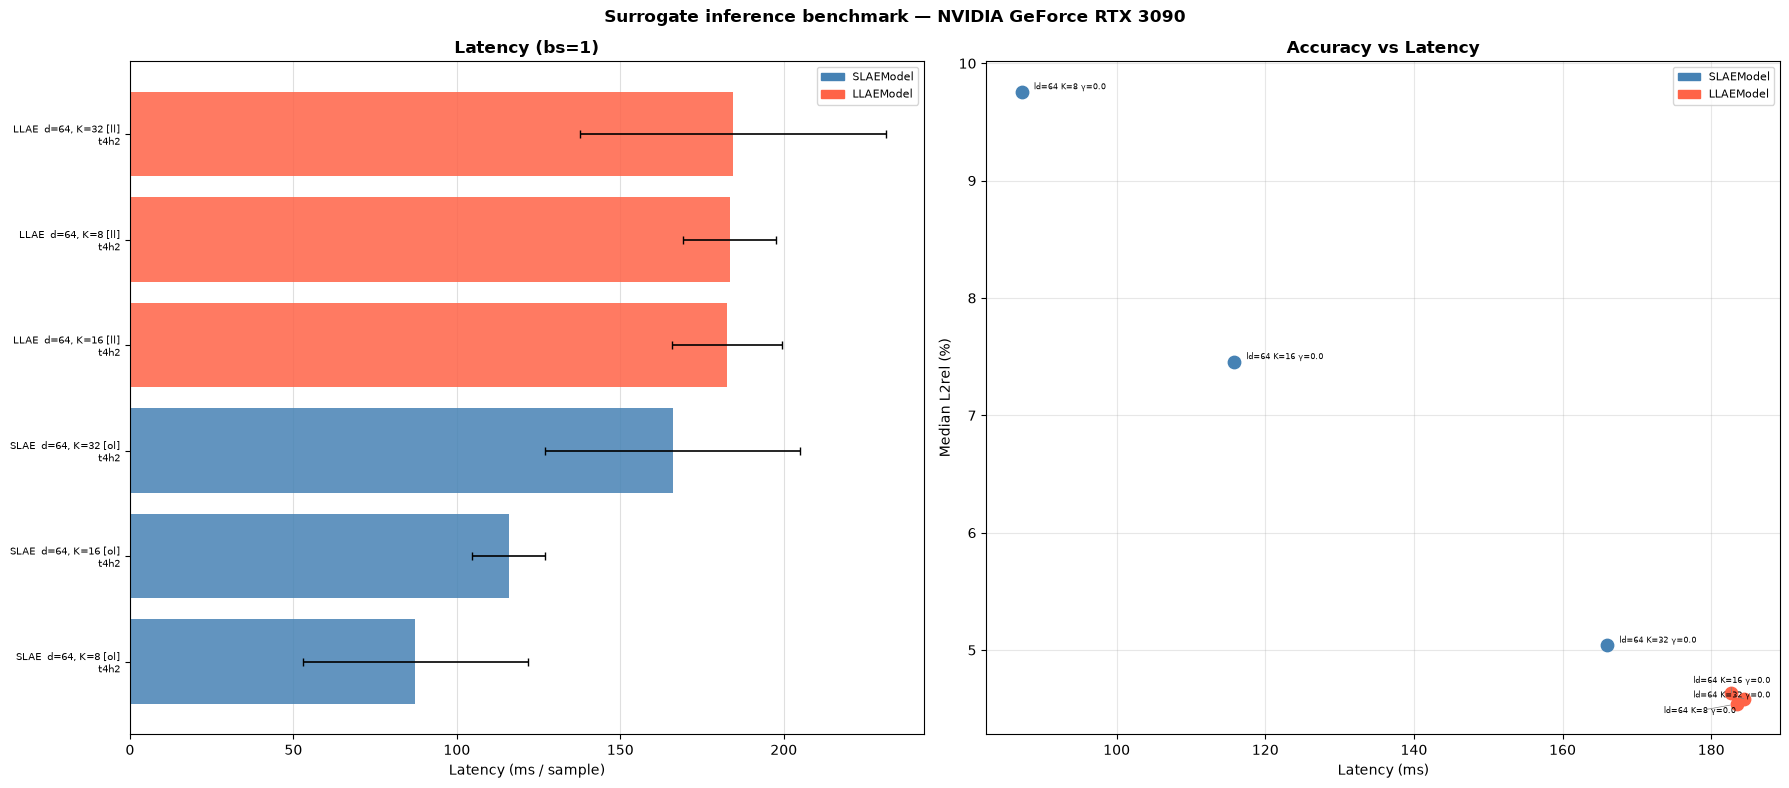

In [33]:

if bench and results:
    common = [n for n in bench if n in results]
    common_sorted = sorted(common, key=lambda n: bench[n]['lat_med'])

    from adjustText import adjust_text

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    col = [PALETTE.get(model_types.get(n, ''), 'gray') for n in common_sorted]

    # ── Latency horizontal bar ────────────────────────────────────────────
    lats = [bench[n]['lat_med'] for n in common_sorted]
    stds = [bench[n]['lat_std']  for n in common_sorted]
    y    = np.arange(len(common_sorted))

    ax1.barh(y, lats, color=col, alpha=0.85, zorder=2)
    ax1.errorbar(lats, y, xerr=stds, fmt='none', color='black', capsize=3, linewidth=1.2, zorder=3)
    ax1.set_yticks(y)
    ax1.set_yticklabels([_pretty_name(n) for n in common_sorted], fontsize=7)
    ax1.set_xlabel('Latency (ms / sample)')
    ax1.set_title('Latency (bs=1)', fontweight='bold')
    ax1.grid(axis='x', alpha=0.4, zorder=0)

    # ── Accuracy vs latency scatter ───────────────────────────────────────
    def _scatter_label(name):
        m = _SURR_PAT.match(name)
        if not m: return name
        sm = _AE_STEM_PAT.match(m.group('ae_stem'))
        if not sm: return name
        return f'ld={sm.group("ld")} K={sm.group("K")} γ={float(sm.group("g"))}'

    texts = []
    for n in common:
        xp = bench[n]['lat_med']
        yp = np.median(results[n])
        ax2.scatter(xp, yp,
                    color=PALETTE.get(model_types.get(n, ''), 'gray'),
                    s=80, zorder=3)
        texts.append(ax2.text(xp, yp, _scatter_label(n), fontsize=6))

    adjust_text(texts, ax=ax2,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, shrinkA=5, shrinkB=5),
                expand_points=(2.0, 2.0), expand_text=(1.5, 1.5))

    ax2.set_xlabel('Latency (ms)')
    ax2.set_ylabel('Median L2rel (%)')
    ax2.set_title('Accuracy vs Latency', fontweight='bold')
    ax2.grid(alpha=0.3)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    for ax in (ax1, ax2):
        ax.legend(handles=legend_handles, fontsize=8)

    gpu_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Surrogate inference benchmark — {gpu_name}', fontweight='bold')
    fig.tight_layout()
    plt.show()
